# Phase 4 — FMPE, Step 3: full 5-D Heston

**Requires `heston_core.py` in the same directory.** This completes the **synthetic** pipeline.

| Step | $V$ | referee | status |
|---|---|---|---|
| 1 | 1-D toy | analytic posterior | passed: FM matched the closed form |
| 2 | 2-D $(v_0,\theta)$ | Fourier pricer (validates $F$) | passed: SBC flat, coverage $|z|<2$, NFE-converged |
| **3 (here)** | **5-D $(\kappa,\theta,\xi,\rho,v_0)$** | none | — |
| 4 | deploy on real NIFTY | none; **misspecified** | separate |

**Nothing is frozen any more.** In Step 2, $\kappa,\xi,\rho$ were fixed placeholders. Here all five are
inferred, so the Phase-3 calibrated values are no longer needed as constants — they matter only for
centring the priors and for Step 4.

**What Step 2 earned us.** The machinery is verified (Step 1, against a closed form) and the simulator
is verified (Step 2, against the Fourier pricer). From here the *only* correctness evidence is
calibration. That is exactly why the earlier steps existed.

**The expected result.** Heston is weakly identified from a single surface. Expect $\kappa$ and $\theta$
to trade off badly, and $\xi$/$\rho$/$v_0$ to have ridges of their own. A broad, strongly correlated
posterior **is the finding**, not a failure — it is the thing a point-estimate optimiser (Phase 3)
structurally cannot produce. If the 5-D posterior comes out narrow and uncorrelated, doubt the
pipeline.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
from scipy.stats import chisquare

from heston_core import simulate_heston

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
rng = np.random.default_rng(SEED)
print("torch:", torch.__version__, "| device:", device)

torch: 2.13.0+cu130 | device: cuda


## 1. Configuration and priors

Parameter order is `heston_core`'s: $(\kappa, \theta, \xi, \rho, v_0)$.

**Prior design notes:**

- $\rho \sim U(-0.95, -0.1)$ — equity skew is negative. Spending prior mass on $\rho > 0$ would waste
  simulations on surfaces that cannot occur in this market.
- $\theta, v_0 \sim U(0.01, 0.09)$ — vol in $[0.10, 0.30]$, bracketing the Phase-3 market ATM of 13–16%.
- **Feller ($2\kappa\theta > \xi^2$) is not enforced.** Rejecting draws would make the training prior
  differ from the prior we claim at deployment, which silently biases every posterior. Full-truncation
  Euler handles $v<0$ by construction. We record the ratio and check afterwards whether the posterior
  cares.
- $\sigma_{\rm obs} = 0.005$ — realistic IV bid-ask (~0.5 vol points), validated in Step 2. Note
  $\sigma_{\rm MC}$ is **common-mode** across the surface (one path set → all maturities), so it does
  not average away and contributes materially to posterior width.

`N_SIM` is raised to 50k: 5-D needs more coverage than 2-D. At ~6 ms/surface that is ~5 min.

In [ ]:
# ---------------- Market / grid (unchanged from Step 2) ----------------
F0      = 1.0
T_GRID  = [0.019, 0.036, 0.077, 0.153, 0.249, 0.403]
Z_GRID  = [-1.5, -0.75, 0.0, 0.75, 1.5]
SIG_REF = 0.15
N_T, N_Z = len(T_GRID), len(Z_GRID)
DIM_X   = N_T * N_Z

# ---------------- V = (kappa, theta, xi, rho, v0) : ALL inferred ----------------
V_LO = np.array([0.5,  0.01, 0.1,  -0.95, 0.01])
V_HI = np.array([5.0,  0.09, 1.5,  -0.10, 0.09])
V_NAMES = [r"$\kappa$", r"$\theta$", r"$\xi$", r"$\rho$", r"$v_0$"]
DIM_V = 5

# ---------------- Simulator ----------------
N_PATHS   = 32_768
N_STEPS   = 400
SIGMA_OBS = 0.005
SIM_CHUNK = 64

# ---------------- Training ----------------
N_SIM  = 200_000
BATCH  = 2048
STEPS  = 40_000
LR     = 1e-3
SIGMA_MIN = 1e-3

# ---------------- Evaluation ----------------
M_EVAL, L_EVAL = 2000, 500

for d in range(DIM_V):
    print(f"{V_NAMES[d]:>10s} ~ U({V_LO[d]:+.2f}, {V_HI[d]:+.2f})")
print(f"\nX: {DIM_X}-D surface | V: {DIM_V}-D | N_SIM={N_SIM:,}")

  $\kappa$ ~ U(+0.50, +5.00)
  $\theta$ ~ U(+0.01, +0.09)
     $\xi$ ~ U(+0.10, +1.50)
    $\rho$ ~ U(-0.95, -0.10)
     $v_0$ ~ U(+0.01, +0.09)

X: 30-D surface | V: 5-D | N_SIM=50,000


In [3]:
def sample_prior(n, rng):
    """(n, 5) draws of (kappa, theta, xi, rho, v0)."""
    return rng.uniform(V_LO, V_HI, size=(n, DIM_V))

def to_unconstrained(v):
    """box -> R^5, per-component logit."""
    u = np.clip((v - V_LO) / (V_HI - V_LO), 1e-6, 1 - 1e-6)
    return np.log(u / (1 - u))

def to_constrained(vt):
    """R^5 -> box. Torch; applied to the flow output."""
    lo = torch.tensor(V_LO, dtype=torch.float32, device=vt.device)
    hi = torch.tensor(V_HI, dtype=torch.float32, device=vt.device)
    return lo + (hi - lo) * torch.sigmoid(vt)

def feller_ratio(V):
    """2*kappa*theta / xi^2. <1 violates Feller. Recorded, never enforced."""
    return 2.0 * V[:, 0] * V[:, 1] / V[:, 2] ** 2

In [ ]:
import os

BLOCK = 5_000   # simulate in blocks; checkpoint after each -> safe to interrupt

def simulate_cached(n, seed, tag):
    """
    Simulate n surfaces, checkpointing to disk every BLOCK. Interrupt-safe: re-running
    resumes where it stopped. Cache key includes EVERY simulator setting, so changing
    N_PATHS / SIGMA_OBS / SIG_REF / N_STEPS forces a fresh run rather than silently
    reusing a mismatched dataset (that mismatch is the train/deploy misspecification bug).
    """
    key  = f"{tag}_N{n}_p{N_PATHS}_s{N_STEPS}_sig{SIGMA_OBS}_ref{SIG_REF}_seed{seed}"
    path = f"cache_{key}.npz"

    # V is drawn deterministically from the seed, so resume is exact.
    V_all = np.random.default_rng(seed).uniform(V_LO, V_HI, size=(n, DIM_V))

    if os.path.exists(path):
        X_done = np.load(path)["X"]
        if X_done.shape[0] >= n:
            print(f"[cache hit] {path}  ({X_done.shape[0]:,} surfaces, 0 min)")
            return V_all, X_done[:n].astype(np.float64)
        print(f"[resume] {X_done.shape[0]:,}/{n:,} already simulated")
    else:
        X_done = np.empty((0, DIM_X), dtype=np.float32)

    rng_sim, t0, start = np.random.default_rng(seed + 999), time.time(), X_done.shape[0]
    while X_done.shape[0] < n:
        s, e = X_done.shape[0], min(X_done.shape[0] + BLOCK, n)
        Xb = simulate_heston(V_all[s:e], T_GRID, Z_GRID, F0, N_PATHS, N_STEPS,
                             SIGMA_OBS, device, rng_sim, sig_ref=SIG_REF, chunk=SIM_CHUNK)
        X_done = np.concatenate([X_done, Xb.astype(np.float32)], axis=0)
        np.savez_compressed(path, X=X_done)            # checkpoint
        done, el = X_done.shape[0] - start, time.time() - t0
        eta = el / done * (n - X_done.shape[0]) / 60
        print(f"  {X_done.shape[0]:6,}/{n:,}  ({el/60:4.1f} min elapsed, ~{eta:4.1f} min left)")
    torch.cuda.empty_cache()
    return V_all, X_done.astype(np.float64)


# ============ now cached: pay once, reuse forever ============
V_train, X_train = simulate_cached(N_SIM, SEED,     "train")
V_val,   X_val   = simulate_cached(4_000, SEED + 1, "val")

assert np.isfinite(X_train).all(), "non-finite IV -- inversion failed; check the strike grid"
fr = feller_ratio(V_train)
print(f"IV range [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Feller ratio: {(fr < 1).mean()*100:.0f}% of prior draws VIOLATE Feller (kept, by design)")

X_MEAN, X_STD = X_train.mean(), X_train.std()
V_tilde     = torch.tensor(to_unconstrained(V_train), dtype=torch.float32, device=device)
X_cond      = torch.tensor((X_train - X_MEAN) / X_STD, dtype=torch.float32, device=device)
V_tilde_val = torch.tensor(to_unconstrained(V_val),   dtype=torch.float32, device=device)
X_cond_val  = torch.tensor((X_val  - X_MEAN) / X_STD, dtype=torch.float32, device=device)
print(f"flow state {tuple(V_tilde.shape)} | context {tuple(X_cond.shape)}")

training set (50000, 30) in 5.6 min
IV range [0.0310, 0.3505]
Feller ratio: 72% of prior draws VIOLATE Feller (kept, by design)
flow state (50000, 5) | context (50000, 30)


## 2. Network and training

Identical to Step 2 apart from `dim_v = 5`. The encoder still maps the 30-D surface to a 128-D context;
the flow now transports a 5-D state.

Watch the **validation loss**. 5-D is a harder target on the same `N_SIM`-per-dimension budget — if val
flattens while train keeps falling, raise `N_SIM` rather than `STEPS`.

In [5]:
class VelocityNet(nn.Module):
    """Conditional velocity field v_theta(V_t, t, Enc(X)); V in R^5, X the 30-D surface."""
    def __init__(self, dim_v=DIM_V, dim_x=DIM_X, d_emb=128, hidden=256, depth=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim_x, d_emb), nn.SiLU(),
                                 nn.Linear(d_emb, d_emb), nn.SiLU())
        layers, d = [], dim_v + 1 + d_emb
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.SiLU()]; d = hidden
        layers += [nn.Linear(hidden, dim_v)]
        self.net = nn.Sequential(*layers)
    def forward(self, v_t, t, x):
        return self.net(torch.cat([v_t, t, self.enc(x)], dim=-1))

net = VelocityNet().to(device)
print("trainable parameters:", sum(p.numel() for p in net.parameters()))

trainable parameters: 253701


step   2500 | train 0.9246 | val 0.9020
step   5000 | train 0.8890 | val 0.8900
step   7500 | train 0.8794 | val 0.8803
step  10000 | train 0.8674 | val 0.8720
step  12500 | train 0.8636 | val 0.8599
step  15000 | train 0.8596 | val 0.8608
train time 0.8 min


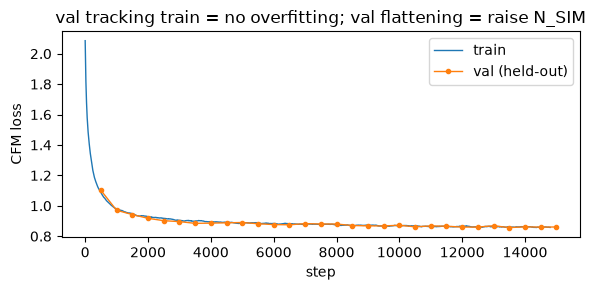

In [6]:
opt   = torch.optim.Adam(net.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)

def cfm_loss(v1, xc):
    v0 = torch.randn_like(v1)
    t  = torch.rand(v1.shape[0], 1, device=device)
    v_t = (1 - (1 - SIGMA_MIN) * t) * v0 + t * v1
    u   = v1 - (1 - SIGMA_MIN) * v0
    return ((net(v_t, t, xc) - u) ** 2).mean()

@torch.no_grad()
def val_loss(n_rep=8):
    net.eval()
    out = float(np.mean([cfm_loss(V_tilde_val, X_cond_val).item() for _ in range(n_rep)]))
    net.train(); return out

t0, tr_hist, va_hist = time.time(), [], []
for step in range(1, STEPS + 1):
    idx = torch.randint(0, N_SIM, (BATCH,), device=device)
    loss = cfm_loss(V_tilde[idx], X_cond[idx])
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    tr_hist.append(loss.item())
    if step % 500 == 0:
        va_hist.append((step, val_loss()))
        if step % 2500 == 0:
            print(f"step {step:6d} | train {np.mean(tr_hist[-500:]):.4f} | val {va_hist[-1][1]:.4f}")
print(f"train time {(time.time()-t0)/60:.1f} min")

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(tr_hist, np.ones(200)/200, mode="valid"), lw=1, label="train")
plt.plot(*zip(*va_hist), "o-", ms=3, lw=1, label="val (held-out)")
plt.xlabel("step"); plt.ylabel("CFM loss"); plt.legend()
plt.title("val tracking train = no overfitting; val flattening = raise N_SIM")
plt.tight_layout(); plt.show()

In [7]:
@torch.no_grad()
def sample_posterior(X_obs, n_samples, nfe=100, chunk=200_000):
    """X_obs: (M, DIM_X) -> (M, n_samples, DIM_V). No simulator calls: this is the amortised part."""
    net.eval()
    X_obs = np.atleast_2d(X_obs); M = X_obs.shape[0]
    xc_all = torch.tensor((X_obs - X_MEAN) / X_STD, dtype=torch.float32, device=device)
    xc_all = xc_all.repeat_interleave(n_samples, dim=0)
    out, dt = [], 1.0 / nfe
    for s in range(0, xc_all.shape[0], chunk):
        xc = xc_all[s:s+chunk]
        v = torch.randn(xc.shape[0], DIM_V, device=device)
        for k in range(nfe):
            t  = torch.full((xc.shape[0], 1), k * dt, device=device)
            k1 = net(v, t, xc)
            k2 = net(v + 0.5 * dt * k1, t + 0.5 * dt, xc)
            v  = v + dt * k2
        out.append(to_constrained(v).cpu().numpy())
    net.train()
    return np.concatenate(out, axis=0).reshape(M, n_samples, DIM_V)

_chk = sample_posterior(X_train[:2], 64)
assert _chk.shape == (2, 64, DIM_V), _chk.shape
print("sampler OK:", _chk.shape)

sampler OK: (2, 64, 5)


## 3. The 5-D posterior

Ten pairwise marginals. This is the plot Phase-3's optimiser could not produce: it reported **one point**
where this shows the whole set of parameters consistent with the data.

**What to look for:**

- **$\kappa$–$\theta$**: expect a strong, tilted ridge. At maturities of a few months the surface
  constrains roughly the *speed × level* combination, not each separately. $\kappa$ is likely close to
  unidentified — a near-prior-width marginal is the honest answer, not a bug.
- **$\rho$, $v_0$**: expect the tightest marginals. $\rho$ controls skew, $v_0$ the short-end level;
  both are directly visible in the surface.
- **$\xi$–$\rho$**: expect moderate correlation (both shape the smile's curvature/slope).
- **Mass against a box edge** → prior too tight; widen and re-run.

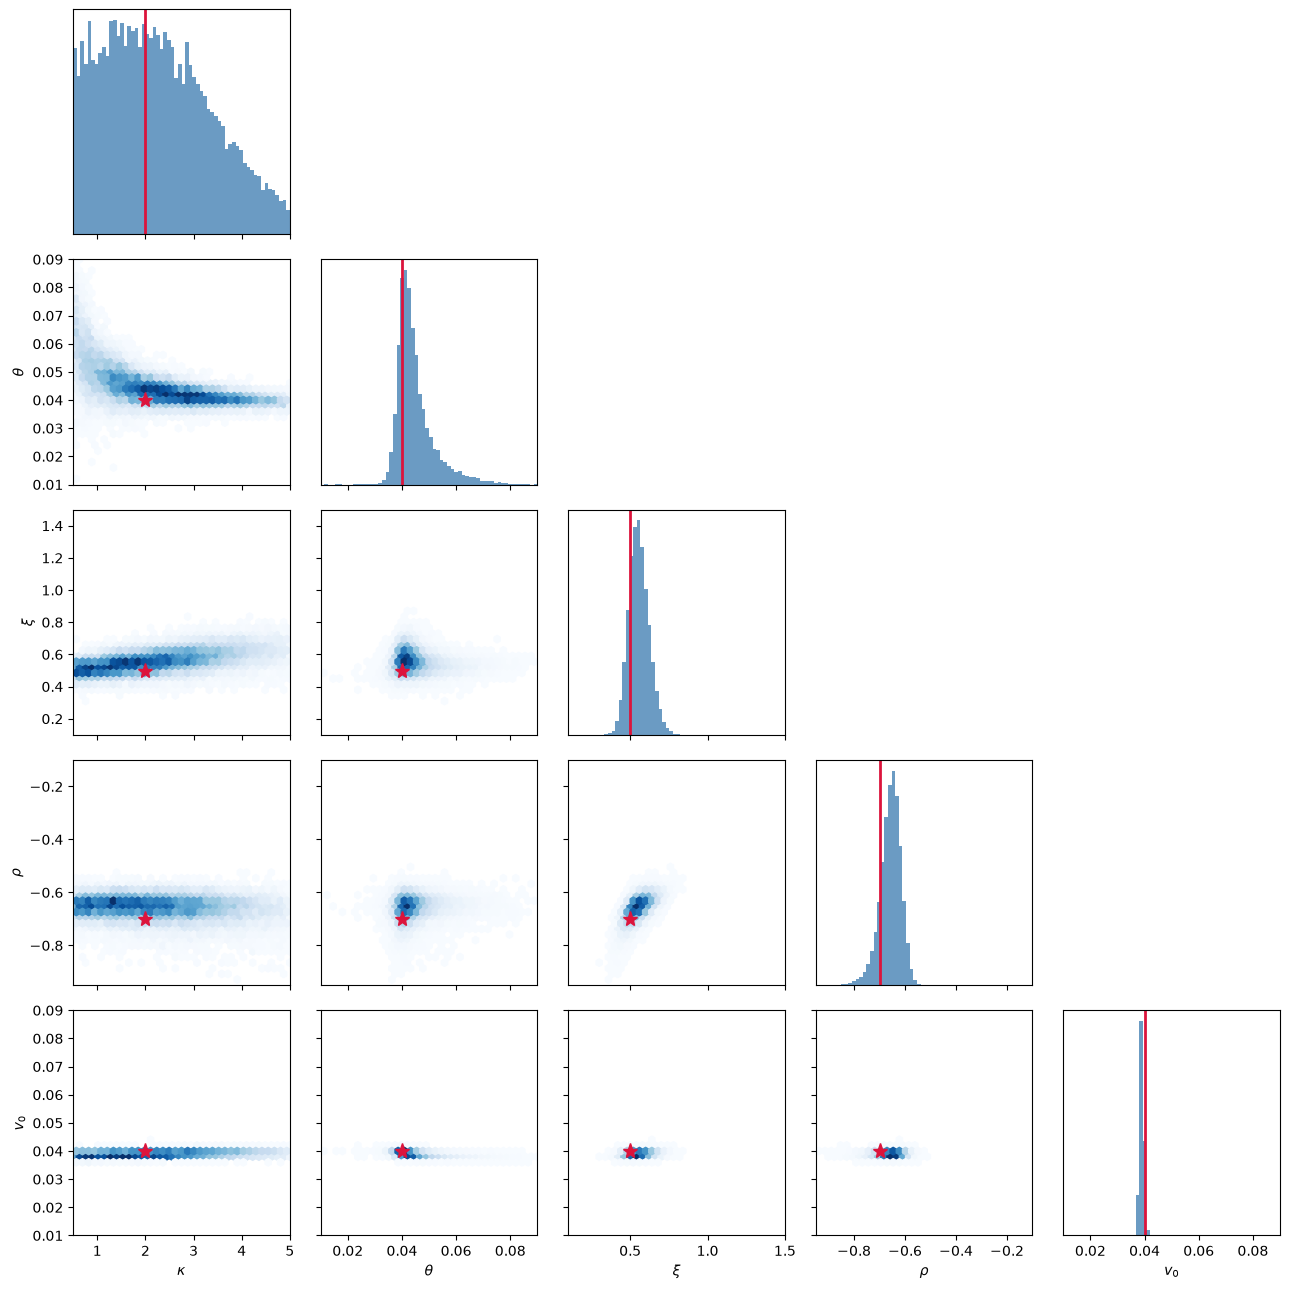

               true  post mean  post std  % of prior
  $\kappa$   2.0000     2.2569    1.0953       24.3%
  $\theta$   0.0400     0.0450    0.0072        9.1%
     $\xi$   0.5000     0.5571    0.0648        4.6%
    $\rho$  -0.7000    -0.6577    0.0423        5.0%
     $v_0$   0.0400     0.0389    0.0008        1.0%

(> ~25% of prior width = essentially unidentified from one surface)

posterior correlation matrix:
            $\kappa$  $\theta$     $\xi$    $\rho$     $v_0$
  $\kappa$    +1.000    -0.606    +0.517    -0.131    +0.283
  $\theta$    -0.606    +1.000    -0.140    +0.114    -0.431
     $\xi$    +0.517    -0.140    +1.000    +0.606    +0.245
    $\rho$    -0.131    +0.114    +0.606    +1.000    +0.053
     $v_0$    +0.283    -0.431    +0.245    +0.053    +1.000


In [8]:
rng_test = np.random.default_rng(0)
V_star = np.array([[2.0, 0.04, 0.5, -0.70, 0.04]])     # a truth to inspect
X_x = simulate_heston(V_star, T_GRID, Z_GRID, F0, N_PATHS, N_STEPS, SIGMA_OBS,
                      device, rng_test, sig_ref=SIG_REF)
post = sample_posterior(X_x, 20_000)[0]                 # (20000, 5)

fig, axes = plt.subplots(DIM_V, DIM_V, figsize=(13, 13))
for i in range(DIM_V):
    for j in range(DIM_V):
        a = axes[i, j]
        if j > i:
            a.axis("off"); continue
        if i == j:
            a.hist(post[:, i], bins=60, range=(V_LO[i], V_HI[i]), density=True,
                   color="steelblue", alpha=.8)
            a.axvline(V_star[0, i], color="crimson", lw=2)
            a.set_yticks([]); a.set_xlim(V_LO[i], V_HI[i])
        else:
            a.hexbin(post[:, j], post[:, i], gridsize=35, cmap="Blues", mincnt=1,
                     extent=(V_LO[j], V_HI[j], V_LO[i], V_HI[i]))
            a.plot(V_star[0, j], V_star[0, i], "*", color="crimson", ms=11)
            a.set_xlim(V_LO[j], V_HI[j]); a.set_ylim(V_LO[i], V_HI[i])
        if i == DIM_V - 1: a.set_xlabel(V_NAMES[j])
        else:              a.set_xticklabels([])
        if j == 0 and i > 0: a.set_ylabel(V_NAMES[i])
        elif j > 0:          a.set_yticklabels([])
plt.tight_layout(); plt.show()

print(f"{'':>10s} {'true':>8s} {'post mean':>10s} {'post std':>9s} {'% of prior':>11s}")
for d in range(DIM_V):
    w = V_HI[d] - V_LO[d]
    print(f"{V_NAMES[d]:>10s} {V_star[0,d]:8.4f} {post[:,d].mean():10.4f} "
          f"{post[:,d].std():9.4f} {post[:,d].std()/w*100:10.1f}%")
print("\n(> ~25% of prior width = essentially unidentified from one surface)")

C = np.corrcoef(post.T)
print("\nposterior correlation matrix:")
print(f"{'':>10s}" + "".join(f"{n:>10s}" for n in V_NAMES))
for i in range(DIM_V):
    print(f"{V_NAMES[i]:>10s}" + "".join(f"{C[i,j]:+10.3f}" for j in range(DIM_V)))

## 4. Metrics

Same two as Steps 1–2, per component. With no analytic posterior and no referee, **Metric B is the
entire correctness argument.**

SBC is now tested with a $\chi^2$ uniformity test rather than by eye — five panels are too many to
eyeball, and mean rank alone is blind to *symmetric* over-confidence (ranks piling at both ends leave
the mean at $L/2$). $p > 0.05$ = consistent with uniform.

**Expect Metric A to look poor for $\kappa$.** That is the identifiability result, not a failure. Metric A
cannot distinguish "model is broken" from "data is uninformative"; Metric B can. That is why both run.

=== Metric A: distance to truth ===
              single  post.mean  post.std   ratio  err % prior
  $\kappa$    0.9189     0.6504    0.7895   1.413        14.5%
  $\theta$    0.0079     0.0057    0.0072   1.399         7.1%
     $\xi$    0.0989     0.0720    0.0889   1.373         5.1%
    $\rho$    0.0695     0.0494    0.0608   1.407         5.8%
     $v_0$    0.0010     0.0007    0.0009   1.441         0.9%
  ratio single/mean: theory ~1.414

=== Metric B: calibration (THE correctness argument) ===
  $\kappa$ coverage 0.9020 (z=+0.30) | SBC chi2 p = 0.916 OK
  $\theta$ coverage 0.8955 (z=-0.67) | SBC chi2 p = 0.398 OK
     $\xi$ coverage 0.8725 (z=-4.10) | SBC chi2 p = 0.009 <-- NOT UNIFORM
    $\rho$ coverage 0.8915 (z=-1.27) | SBC chi2 p = 0.576 OK
     $v_0$ coverage 0.9050 (z=+0.75) | SBC chi2 p = 0.054 OK
  |z| < 2 and p > 0.05 -> calibrated


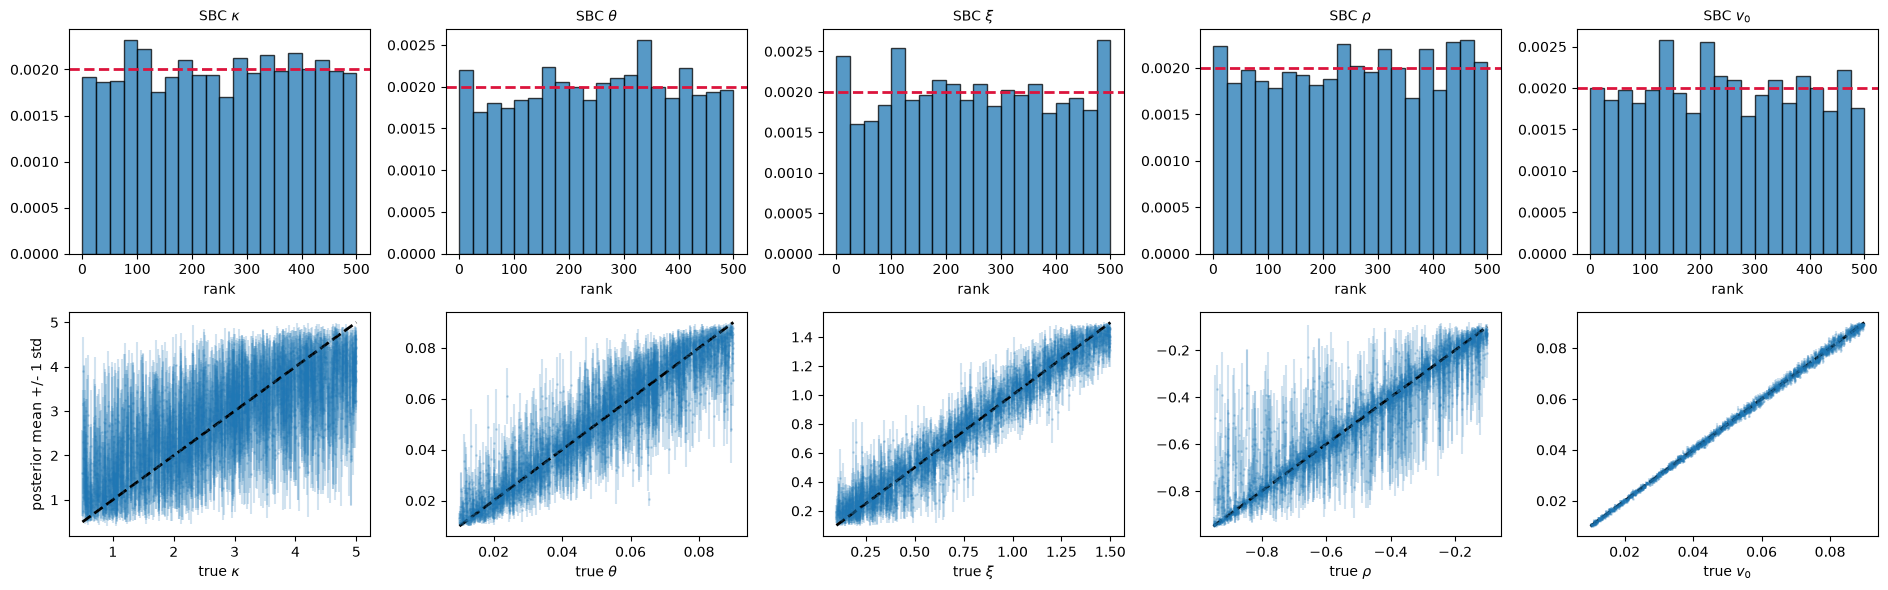


Feller: 71% of truths violate. Mean posterior std:
    $\kappa$  violating 0.7211 | satisfying 0.9546
    $\theta$  violating 0.0071 | satisfying 0.0077
       $\xi$  violating 0.0849 | satisfying 0.0985
      $\rho$  violating 0.0338 | satisfying 0.1259
       $v_0$  violating 0.0009 | satisfying 0.0009


In [9]:
V_true = sample_prior(M_EVAL, rng_test)
X_test = simulate_heston(V_true, T_GRID, Z_GRID, F0, N_PATHS, N_STEPS, SIGMA_OBS,
                         device, rng_test, sig_ref=SIG_REF, chunk=SIM_CHUNK)
posts = sample_posterior(X_test, L_EVAL)                # (M, L, 5)

print("=== Metric A: distance to truth ===")
print(f"{'':>10s} {'single':>9s} {'post.mean':>10s} {'post.std':>9s} {'ratio':>7s} {'err % prior':>12s}")
for d in range(DIM_V):
    w  = V_HI[d] - V_LO[d]
    es = np.abs(posts[:,0,d] - V_true[:,d]).mean()
    em = np.abs(posts[:,:,d].mean(1) - V_true[:,d]).mean()
    sd = posts[:,:,d].std(1).mean()
    print(f"{V_NAMES[d]:>10s} {es:9.4f} {em:10.4f} {sd:9.4f} {es/em:7.3f} {em/w*100:11.1f}%")
print("  ratio single/mean: theory ~1.414")

print("\n=== Metric B: calibration (THE correctness argument) ===")
se_c = np.sqrt(0.9 * 0.1 / M_EVAL)
for d in range(DIM_V):
    lo, hi = np.percentile(posts[:,:,d], 5, axis=1), np.percentile(posts[:,:,d], 95, axis=1)
    cov = np.mean((lo <= V_true[:,d]) & (V_true[:,d] <= hi))
    rk  = (posts[:,:,d] < V_true[:,d,None]).sum(1)
    chi = chisquare(np.histogram(rk, bins=20, range=(0, L_EVAL))[0])
    print(f"{V_NAMES[d]:>10s} coverage {cov:.4f} (z={(cov-0.9)/se_c:+5.2f}) | "
          f"SBC chi2 p = {chi.pvalue:.3f} {'OK' if chi.pvalue > 0.05 else '<-- NOT UNIFORM'}")
print("  |z| < 2 and p > 0.05 -> calibrated")

fig, ax = plt.subplots(2, DIM_V, figsize=(19, 6))
for d in range(DIM_V):
    rk = (posts[:,:,d] < V_true[:,d,None]).sum(1)
    ax[0,d].hist(rk, bins=20, range=(0, L_EVAL), density=True, alpha=.75, edgecolor="k")
    ax[0,d].axhline(1.0/L_EVAL, color="crimson", ls="--", lw=2)
    ax[0,d].set_title(f"SBC {V_NAMES[d]}", fontsize=10); ax[0,d].set_xlabel("rank")
    ax[1,d].errorbar(V_true[:,d], posts[:,:,d].mean(1), yerr=posts[:,:,d].std(1),
                     fmt=".", alpha=.2, ms=2)
    ax[1,d].plot([V_LO[d], V_HI[d]], [V_LO[d], V_HI[d]], "k--", lw=2)
    ax[1,d].set_xlabel(f"true {V_NAMES[d]}")
ax[1,0].set_ylabel("posterior mean +/- 1 std")
plt.tight_layout(); plt.show()

# Does Feller violation change identifiability?
fr_true = feller_ratio(V_true)
viol = fr_true < 1
if viol.sum() > 50 and (~viol).sum() > 50:
    print(f"\nFeller: {viol.mean()*100:.0f}% of truths violate. Mean posterior std:")
    for d in range(DIM_V):
        print(f"  {V_NAMES[d]:>10s}  violating {posts[viol,:,d].std(1).mean():.4f}"
              f" | satisfying {posts[~viol,:,d].std(1).mean():.4f}")

## 5. Reading the result — and what the synthetic pipeline established

**If all five SBC $p > 0.05$ and coverage $|z| < 2$:** the synthetic pipeline is complete and validated
end to end. The posterior widths are then a *physical* statement about Heston — how much a single
option surface can say about each parameter — not an artefact of the method.

**If SBC fails on some component**, in order of likelihood:
1. `N_SIM` too small for 5-D — check whether val flattened while train fell. Fix: more simulations.
2. Train/deploy mismatch — `N_PATHS`, `SIGMA_OBS`, `X_MEAN`/`X_STD` must be identical in both.
3. Under-trained flow — raise `STEPS`.

**The three results to present:**

1. **Verification chain.** Step 1 validated the posterior machinery against a closed form; Step 2
   validated the simulator against an independent Fourier pricer; Step 3 inherits both. Each step had
   an external check, and the last one has calibration.
2. **Identifiability.** The 5-D posterior shows *which* parameters a single surface constrains and which
   it cannot. Phase-3's optimiser reported one point on that ridge with false confidence — including
   $\rho$ moving the wrong way, $-0.70 \to -0.51$, against an obviously skewed market. The posterior
   explains why that happened.
3. **Amortisation.** One training run; any surface thereafter in milliseconds, with no simulation.

**Known limitation, to state rather than hide.** Everything above is *self-consistent synthetic*: the
data was generated by the same model used to infer. Step 4 breaks that. Phase 3 already established
that one-factor Heston cannot span 0.02y–0.40y, and the Euler discretisation bias (~0.0007 vol pts) no
longer cancels once the data is real. Under misspecification the posterior stays narrow and is simply
wrong. Either restrict to the 0.08–0.40y band, or report the misspecification as a finding — it is a
legitimate result, but it must be an explicit choice made in advance, not a surprise.